# Chatter To Choices: Evaluating Collaborative Filtering Methods for Personalized Stock Recommendation Using StockTwits Data

## Abstract

In this paper, the effectiveness of a personalized stock recommendation system based on collaborative filtering is investigated. A user-item utility matrix constructed based on user-asset sentiment interactions is used to compare the performance of four recommendation algorithms: Popularity baseline, User-User collaborative filtering, Item-Item collaborative filtering, and Alternating Least Squares (ALS) Latent Factor collaborative filtering. The performance of the algorithms is measured using Monte Carlo cross-validation in conjunction with standard holdout sets and using NDCG@50, Recall@50, and Diversity@50 as performance metrics.

The experimental results demonstrate that the four algorithms have a consistent performance ranking. ALS produces the best ranking quality and retrieval performance in terms of the highest mean NDCG@50 and mean Recall@50 values, while the Popularity baseline algorithm is the least effective. The mean Diversity@50 values for all algorithms are high and similar to each other, indicating that the improved recommendation relevance does not lead to a degradation in recommendation diversity.

The performance comparison indicates that the Latent Factor collaborative filtering approach is more appropriate for the sparse sentiment-based stock recommendation system compared to the User-User or Item-Item collaborative filtering approaches.

To demonstrate downstream usefulness, the best-performing recommender was integrated into a Black-Litterman–Markowitz portfolio-construction pipeline. The top recommended assets were used as personalized inputs for portfolio optimization, producing a positive but volatile out-of-sample cumulative return path and outperforming most randomly generated benchmark portfolios from the same candidate set. Overall, the study identifies ALS as the strongest recommender for this setting and shows that sentiment-based recommendation outputs can be operationalized within a conventional portfolio-allocation framework.

## Problem Statement

Can sparse, explicit, binary StockTwits investor–stock sentiment interactions be used to generate meaningful personalized stock recommendations and inform portfolio optimizer inputs?

## Motivation

Retail investors are increasingly using online brokerages and social-media-type platforms to inform and execute their investment decisions. One such platform featured in this project, Stocktwits, is built around real-time market discussion, sentiment, watchlists, and trending conversations across stocks, ETFs, and crypto. This study was motivated by the possibility of explicit sentiment tags to be levaraged to create personalized, yet reasonably economically viable recommendations for discovery, idea generation, and decision support. The online nature of the retail investment activity also provides an avenue recommenders such as these to be propagated.

#### Disclaimer: 
This study is intended solely for academic and research purposes and does not constitute financial, investment, or trading advice. Any recommendations, rankings, or portfolio outputs presented are methodological demonstrations based on historical data and modeling assumptions, and should not be interpreted as a suggestion to buy, sell, or hold any security or financial asset.

## Data Sources

### In the interest of brevity, the actual gathering of data from these sources is done in files **scrape_stocktwit.ipynb** and **scrape_yfinance.ipynb**. Refer to those for more detail.
### 1. Stocktwits
StockTwits-from-2008-to-2022 is a large-scale [1], longitudinal implicit-feedback dataset for financial recommendation benchmarking. It provides a complete record of StockTwits posts through 2022, covering more than 7 million active users and over 550 million posts since 2008. At minimum, the released data include anonymous user IDs, message timestamps, message text, ticker mentions, and optional user-declared bullish/bearish sentiment. The repository exposes this information through CSV tables such as symbols (user–message–ticker records), messages (message text), feature_wo_messages (user/timestamp/reply/symbol metadata), and sentiment-focused tables. `The study focuses on records with user-timestamp-symbol-sentiment_tag completed. Sentiment tags explicitly given (bullish/positive or bearish/negative) are treated as binary ratings for the purposes of this project.`
**At the time the data was accessed, records with sentiment tags were available only up to 2017.** As such, 2017 is the target date for the recommendation systems tested. 
### 2. hanshof/sp500_constituents
This study uses the hanshof/sp500_constituents GitHub repository as a secondary data source for S&P 500 index membership [2]. The repository contains a historical constituent file, sp_500_historical_components.csv, which records S&P 500 membership over time from 1996-01-02 onward, allowing ticker-level filtering against the index composition for a target date or year such as 2017.
### 3. Yahoo Finance (yfinance Unofficial Python API Endoint Wrapper)
Yahoo Finance data was accesed through yfinance, an open-source Python wrapper that provides convenient programmatic access to Yahoo Finance’s publicly available APIs [3]. The library supports retrieval of ticker-level data, bulk downloads, market summaries, search/news results, screening queries, sector and industry information, and live streaming interfaces. `Because yfinance is an unofficial wrapper rather than an officially supported Yahoo Finance developer product, it should be treated as an access library for Yahoo Finance data rather than as an independent primary data source.`

## Methodology

### Overview
This study treats personalized stock recommendation as a collaborative-filtering problem using investor-stock interactions derived from StockTwits messages with explicitly tagged tickers. A sparse user-item utility matrix is used to compare popularity-based, neighborhood-based, and ALS latent-factor recommenders under Monte Carlo cross-validation using NDCG@K, Recall@K, and Diversity@K.

The best-performing recommender is then integrated into a Markowitz portfolio-optimization framework to illustrate practical use, with portfolio performance compared against random allocations through cumulative returns.

### Data Filtering
#### 1. User-Item Interactions
As previously stated, all Stocktwits records with any nulls in user ID, timestamp, symbol, and sentiment tags were filtered out. 
- User ID is necessary to keep persistent identifiers for users and their interactions. 
- Timestamp was initially kept to identify the **latest** interaction of a user with a given item. Only the latest interaction is considered for each user-item interaction.
- Asset symbols were required from each record, as this is the exact attribute that identifies the item with which the user has interacted with.
- Sentiments (bearish or bullish) were binary ratings of a user towards their opinion on an an asset's performance. `As previously stated, the Stocktwits platform allows users to explicitly include these in each message.` It is not derived from text signals in the message.
#### 2. Item Scope
A key challenge with the dataset was the sparsity of the matrix. It is the assumption of the proponents that the largest market-cap assets traded in the New-York Stock Exchange would have some of the most interacted-with items in the dataset. As such, only messages that contained at least one symbol from any S&P500 components (in its January 2017 iteration) were kept. Even then, only 359 of the ~500 components in the S&P500 index had at least one interaction in the dataset. This is attributed to the fact that some of those listed may not have yet been known or even founded by the end of the dataset's cut-off date. Given that, Sparsity was at ~99.03%.
#### 3. Returns Data for Portfolio Generation
Daily returns were then computed using percentage changes in closing prices on a per-ticker basis. Because the first return of each series is undefined, rows containing missing return values are removed. 
#### 4. On the Exclusion of Messages
`As this is not a sentiment analysis study in the classic sense of quantifying positive or negative sentiments from text data, the actual messages attached to each Stocktwits record corresponding to the original platform post is not included in the scope to reduce memory complexity. Using the messages to derive sentiment would have been a form of implicit rating, and is out of scope for this study.`
#### 5. Date Cut-Off
Because the dataset only holds records until 2017, only records within this year are considered. It is considered that economic conditions from as recent as 1 year before reflect a different economic reality [4]. Sentiments are assumed to reflect this.

### Data Preprocessing
The preprocessing pipeline produces two aligned inputs:  
(1) a sparse user-item utility matrix from StockTwits sentiment data, and  
(2) a daily asset-returns matrix from S\&P 500 price data.

#### 1. Interaction extraction and matrix construction
Raw StockTwits data are reduced to investor ID, asset ticker, and sentiment label. Explicit bullish tags are encoded as $1.0$, explicit bearish tags as $0.0$, and all other cases as missing, yielding

$$
R = \{r_{ui}\}_{u=1,i=1}^{U,I},
$$

where $r_{ui}=1$ denotes a bullish interaction, $r_{ui}=0$ a bearish interaction, and $r_{ui}=\mathrm{NaN}$ no observed interaction. Missing values are preserved as unobserved rather than treated as negative preference.

`Only assets included in the S&P 500 price data were included as items in the utility matrix`

#### 2. Market-price preprocessing
S\&P 500 price data are cleaned separately to form a daily returns matrix. Dates are parsed, the benchmark index $\hat{\text{GSPC}}$ is excluded from the investable universe, and closing prices are converted into simple returns:

$$
r_{i,t} = \frac{P_{i,t} - P_{i,t-1}}{P_{i,t-1}}.
$$

The cleaned data are then pivoted into a date-by-ticker matrix for optimization and benchmarking.

#### 3. Holdout generation and evaluation setup
Recommendation quality is evaluated through Monte Carlo cross-validation with repeated random holdout splits. For each seed, users with enough positive interactions are eligible, and a fraction of each user's bullish assets is withheld for testing. If

$$
\mathcal{P}_u = \{ i : r_{ui} = 1 \},
$$

then the holdout set $\mathcal{H}_u \subseteq \mathcal{P}_u$ is sampled such that

$$
|\mathcal{H}_u| = \max\left(1, \left\lfloor \text{test\_frac} \cdot |\mathcal{P}_u| \right\rfloor \right).
$$

During evaluation, only items unobserved in training are recommendable:

$$
\mathcal{C}_u = \{ i : r^{\text{train}}_{ui} \text{ is missing} \}.
$$

#### 4. Model-specific preprocessing and portfolio link
For neighborhood-based collaborative filtering, missing values are temporarily filled with zeros for cosine-similarity computation, while original missingness is preserved for recommendation masking. Diversity is measured from an item-item similarity matrix derived from the training data:

$$
\mathrm{Diversity@K}(L_u) = 1 - \frac{1}{\binom{K}{2}} \sum_{i < j,\; i,j \in L_u} S(i,j).
$$

After evaluation, the best recommender is aligned to the same ticker universe as the returns matrix so that its outputs can be translated into investor views for the portfolio stage.
  
### Summary
Overall, preprocessing converts StockTwits sentiment data into a recommendation dataset with explicit train-test separation and prepares aligned return data for portfolio construction. This enables fair recommender comparison and downstream integration with Markowitz optimization.

### Evaluation Methodology
This study evaluates recommendation quality using repeated Monte Carlo holdout splits on the user-item utility matrix. For each random seed, the same train-test split is used for all recommenders so that Popularity, User-User, Item-Item, and ALS are compared on an identical ranking task.

#### 1. Holdout construction
For each seed, a user-level holdout is created by randomly masking a fraction of observed bullish interactions from eligible users. Only users with at least two positive interactions are considered, and approximately 20\% of each eligible user's bullish assets are withheld:

$$
\mathcal{P}_u = \{ i : r_{ui} = 1 \}, \qquad
|\mathcal{H}_u| = \max\left(1,\left\lfloor 0.2 \cdot |\mathcal{P}_u| \right\rfloor\right).
$$

The retained observations form the training matrix, while the hidden bullish interactions form the test set.

#### 2. Common ranking setup
All models recommend only assets that are unobserved in the training matrix:

$$
\mathcal{C}_u = \{ i : r_{ui}^{\text{train}} \text{ is missing} \}.
$$

This same candidate set is used for every recommender. Popularity ranks assets by training-set popularity, User-User uses cosine \(k\)-nearest-neighbor neighborhoods, Item-Item uses cosine item similarity with top-\(k\) pruning, and ALS ranks assets using latent scores from $UV^\top$.

#### 3. Tie-break
Without a robust way to justify tie-breakers, alphabetic ordering of the asset's symbols were used to break ties in recommendation rankings.


#### 4. Metric calculation and aggregation
For each user in each Monte Carlo split, every recommender produces a ranked list over the same unseen candidate set. From this list, NDCG@50, Recall@50, and Diversity@50 are computed at the user level. These user-level values are then averaged within each split to obtain one seed-level score per model, and the final reported results are the mean and standard deviation of those seed-level scores across all random seeds.

**NDCG@50.**  
For each user, the recommender's ranked list is matched against the held-out test items, where only hidden bullish assets are treated as relevant. Let the resulting relevance vector be

$$
\mathrm{rel}_u = (rel_{u1}, rel_{u2}, \dots).
$$

Discounted Cumulative Gain is computed as

$$
\mathrm{DCG@50}_u
=
\sum_{j=1}^{50}
\frac{rel_{uj}}{\log_2(j+1)}.
$$

This is normalized by the Ideal DCG, computed by placing all of that user's held-out relevant items first within the same candidate set:

$$
\mathrm{NDCG@50}_u
=
\frac{\mathrm{DCG@50}_u}{\mathrm{IDCG@50}_u}.
$$

If a user has no relevant held-out item, the value is treated as missing. The model's seed-level NDCG@50 is the mean of valid user-level NDCG@50 values.

**Recall@50.**  
Recall is computed from the same ranked relevance vector:

$$
\mathrm{Recall@50}_u
=
\frac{\text{number of held-out relevant items appearing in the top 50}}
{\text{total number of held-out relevant items for user } u}.
$$

Because the test set contains only held-out positive interactions, the denominator is simply the number of hidden bullish assets for that user. Users with no held-out positive item are excluded, and the seed-level Recall@50 is the mean across valid users.

**Diversity@50.**  
Diversity is computed from the top-50 recommended items regardless of relevance. Using an item-item cosine similarity matrix derived from the training data, intra-list diversity is defined as

$$
\mathrm{Diversity@50}(L_u)
=
1 - \frac{1}{\binom{50}{2}}
\sum_{i<j,\; i,j \in L_u} S(i,j),
$$

where \(S(i,j)\) is the similarity between recommended assets \(i\) and \(j\). Higher values indicate less redundancy within the recommendation list. If fewer than two items are recommended, diversity is set to \(0\). The seed-level Diversity@50 is the mean of user-level diversity values.

**Aggregate reporting.**  
Aggregation is therefore done in two stages:

1. compute user-level NDCG@50, Recall@50, and Diversity@50 for each recommender within one split, then average across users to obtain one seed-level score per metric;  
2. repeat across random seeds, then report the overall mean and standard deviation of the seed-level scores for each model.

This means the final tables summarize repeated user-level averages across multiple holdout splits, rather than results from only one partition.

#### 5. Using K = 50
Using @50 for the evaluation metrics above was considered because a broader shortlist of recommendations is more useful in the sparse utility matrix, where ratings are few and the list of items is large.

#### 6. Popularity as Benchmark
Popularity was included as a standard non-personalized benchmark to compare against personalized collaborative-filtering methods [5].

#### Addendum:
To illustrate applicability of recommendations, the resulting portfolios were evaluated.   

For a single out-of-sample window, the optimized Black-Litterman portfolio was constructed on the investor’s top-N recommended assets, with the prior covariance matrix estimated using the Ledoit-Wolf shrinkage estimator on the training return matrix. Its realized cumulative return was then compared against the empirical distribution of many Dirichlet-randomized long-only portfolios generated on the same asset universe and evaluated over the same test window.


### Note:
Any steps whose execution is unclear from the code could be using functions from any of the following modules or notebooks: 
- scrape_stocktwit.ipynb
- scrape_yfinance.ipynb
- data_prep.py
- utils.py
- black_litterman_recommender.py
- markowitz_analysis.py
- markowitz_plots.py

###

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import black_litterman_recommender as blr
import importlib
from concurrent.futures import ThreadPoolExecutor, as_completed
importlib.reload(blr)
import utils as ut
import data_prep
import markowitz_analysis as ma
import markowitz_plots as mp
from sklearn.covariance import LedoitWolf

## Exploratory Data Analysis

In [2]:
df = pd.read_csv('cleaned_data.csv', index_col=0)
df = df[df['created_at'] >= '2017-01-01']
df_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notna().sum(),
    "nulls": df.isna().sum(),
    "nunique": df.nunique()
})
df_summary

,dtype,non_null,nulls,nunique
user_id,int64,113352,0,32545
created_at,object,113352,0,101610
sentiment,object,113352,0,2
symbol,object,113352,0,359


### Missingness
As a result of some pre-processing done during the data gathering, no nulls remain. Rules as described in the Data Filtering section were applied at that stage.

In [3]:
df.duplicated().sum()

np.int64(0)

### Duplicates
As a result of some pre-processing done during the data gathering, no duplicates remain. Rules as described in the Data Filtering section were applied at that stage. `Only the latest rating on an asset per user were kept.`

In [4]:
sent_counts = df["sentiment"].value_counts(dropna=False)
sent_props = df["sentiment"].value_counts(normalize=True, dropna=False) * 100

pd.DataFrame({
    "count": sent_counts,
    "pct": sent_props.round(2)
})

,count,pct
sentiment,,
Bullish,85288,75.24
Bearish,28064,24.76


### Sentiment Distribution
The dataset is positive (bullish) skewed with 75.24% being positive and 24.76% being negative (bearish).

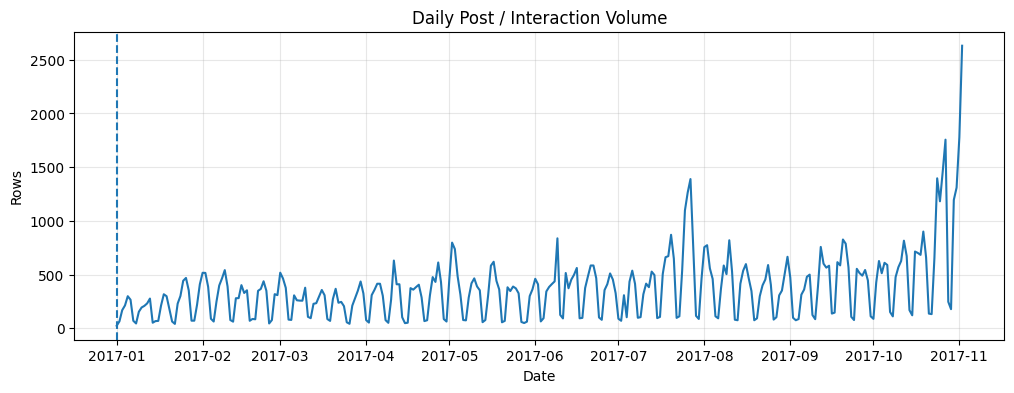

In [5]:
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True)
daily_counts = (
    df
    .set_index("created_at")
    .resample("D")
    .size()
)

plt.figure(figsize=(12, 4))
plt.plot(daily_counts.index, daily_counts.values)
plt.axvline(pd.Timestamp("2017-01-01", tz="UTC"), linestyle="--")
plt.title("Daily Post / Interaction Volume")
plt.xlabel("Date")
plt.ylabel("Rows")
plt.grid(True, alpha=0.3)
plt.show()

### Interaction Volume
The daily interaction-volume series for 2017 shows strong periodic fluctuations and a mild upward trend over time, with several transient spikes and a sharp increase near the end of the sample. `Because preprocessing removed duplicates by retaining only the latest rating per user-asset pair, the figure reflects filtered usable observations for modeling rather than raw social-media posting intensity.`

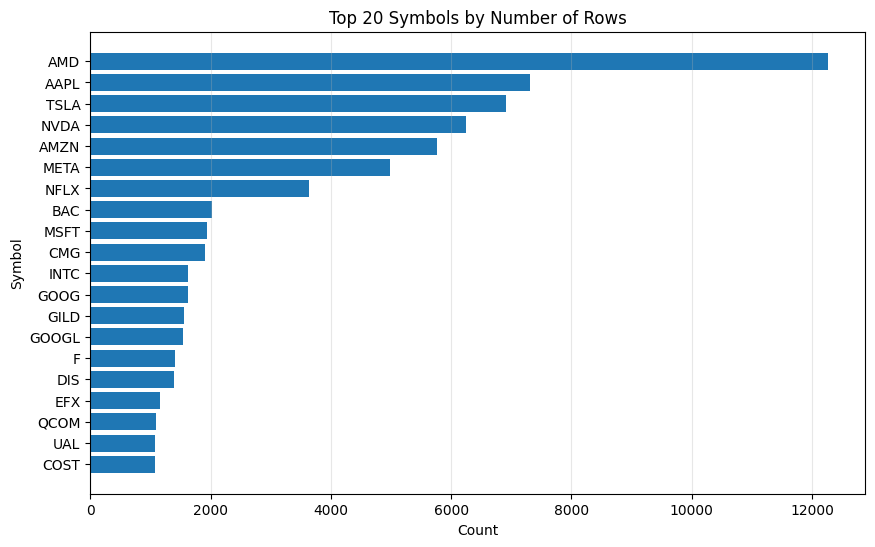

In [6]:
top_symbols = df["symbol"].value_counts().head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_symbols.index[::-1], top_symbols.values[::-1])
plt.title("Top 20 Symbols by Number of Rows")
plt.xlabel("Count")
plt.ylabel("Symbol")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

### Distribution of Interactions By Symbol
The interactions across symbols is highly concentrated towards the top. AMD is most frequently occuring by a wide margin, followed by AAPL, TSLA, NVDA, and AMZN. User attention is largely concentrated on a small set of large, high-visibility assets.

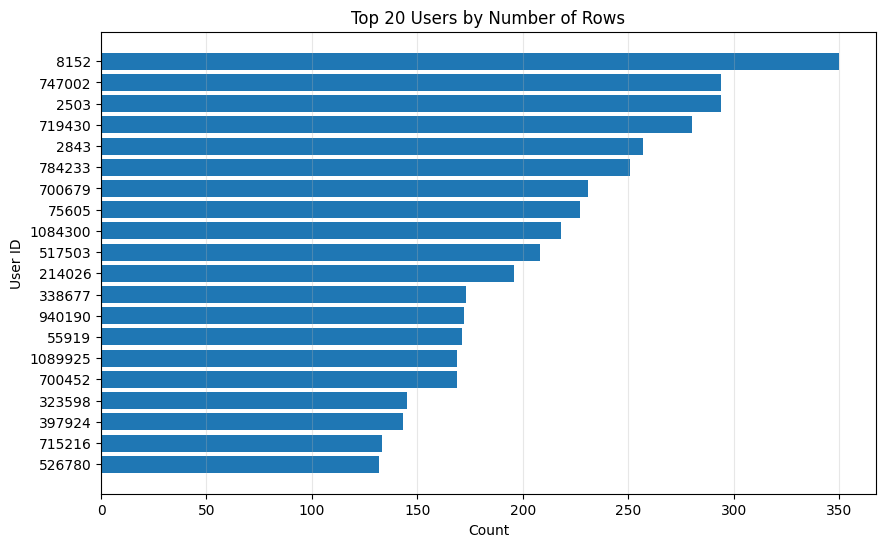

In [7]:
top_users = df["user_id"].value_counts().head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_users.index.astype(str)[::-1], top_users.values[::-1])
plt.title("Top 20 Users by Number of Rows")
plt.xlabel("Count")
plt.ylabel("User ID")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

### User Activity
User posting is also uneven, with a small set of users contributing the most in terms of retained interactions compared to others. The most active user has rated 350 items at least once.

In [8]:
user_activity = df["user_id"].value_counts()
user_activity.describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count    32545.000000
mean         3.482931
std          7.950875
min          1.000000
50%          2.000000
90%          7.000000
95%         11.000000
99%         28.000000
max        350.000000
Name: count, dtype: float64

### Symbols per User

User activity is highly concentrated and right-skewed. While the average user contributes 3.48 retained interactions, the median is only 2, and 99% of users contribute 28 or fewer rows, indicating that the dataset is dominated by low-activity users with only a small number of highly active accounts.  

count      359.000000
mean       315.743733
std       1024.678588
min          1.000000
50%         64.000000
90%        604.600000
95%       1081.400000
99%       5971.380000
max      12273.000000
Name: count, dtype: float64


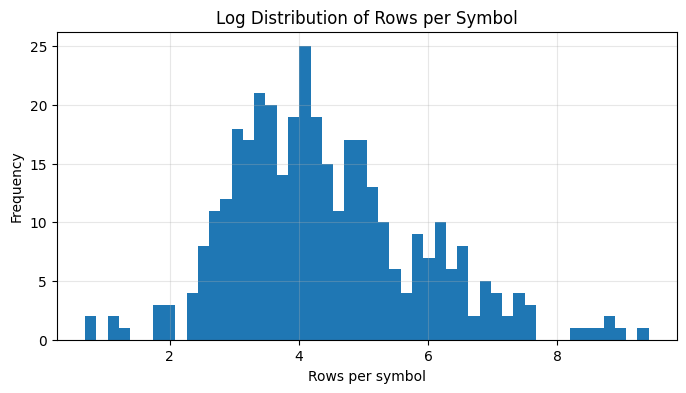

In [9]:
symbol_activity = df["symbol"].value_counts()

print(symbol_activity.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(symbol_activity), bins=50)
plt.title("Log Distribution of Rows per Symbol")
plt.xlabel("Rows per symbol")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

### Symbol Activity
Symbol-level activity is highly right-skewed, with a median of only 64 retained rows per symbol but a mean of 315.74 due to a small number of extremely active tickers. This indicates a long-tail distribution in which a few symbols dominate observed sentiment activity while many others have much more sparse occurence.

In [10]:
symbol_sent = (
    df.groupby(["symbol", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

symbol_sent["total"] = symbol_sent.sum(axis=1)
symbol_sent = symbol_sent.sort_values("total", ascending=False)

symbol_sent.head(20)

sentiment,Bearish,Bullish,total
symbol,,,
AMD,2206,10067,12273
AAPL,1840,5478,7318
TSLA,2588,4330,6918
NVDA,1563,4692,6255
AMZN,1368,4398,5766
META,1230,3747,4977
NFLX,1328,2301,3629
BAC,418,1614,2032
MSFT,281,1667,1948


### Per-Symbol Sentiments
The top symbols are predominantly bullish-skewed, with most high-volume tickers exhibiting substantially more bullish than bearish observations. However, several assets such as EFX and UAL display bearish-dominant sentiment, while CMG is nearly balanced, indicating that the dataset captures asset-specific variation in sentiment rather than only broad popularity.

In [11]:
util = blr.stocktwits_to_sentiment_matrix(
    df,
    user_col = "user_id",
    asset_col = "symbol",
    sentiment_col = "sentiment",
    bullish_values = (1, "bullish", "Bullish", "BULLISH"),
    bearish_values = (-1,"bearish", "Bearish", "BEARISH"),
)
stock_data_df, stock_data, stock_prices, returns_matrix = data_prep.load_sp500_data("sp500long.csv")
util = util[returns_matrix.columns.intersection(util.columns)]
util

symbol,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WEC,WELL,WFC,WMT,WST,XEL,XOM,XYL,ZBRA,ZTS
user_id,,,,,,,,,,,,,,,,,,,,,
5,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1250048,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1250486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1250559,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Utility Matrix
The utility matrix was created with Bullish ratings mapped as 1.0, Bearish ratings mapped as 0.0, and unrated intersections kept as null.

In [12]:
sparsity = (1 - util.notna().sum().sum() / util.size) * 100
print(f"{sparsity:.2f}%")

99.03%


### Utility Matrix Sparsity
The resulting utility matrix is very sparse, with 99.03% of user-item intersections being unrated. `From this, the proponents assumed that Latent-Factor Collaborative filtering may be the best candidate among the short-listed recommender systems tested because there is little overlap for Neighborhood-based recommenders to work with.`

## Results and Discussion

In [13]:
U, V, _ = blr.als_explicit(util, 8, lam=0.1, max_iter=50, tol=1e-4, seed=42)

In [14]:
seeds = [42, 67, 69, 1337, 420]
k = 50
res = blr.evaluate_recommenders_parallel(
    util=util,
    U=U,
    V=V,
    seeds=seeds,
    k=50,
    top_k_neighbors=25,
    max_workers=8,
    backend="process",
)

df_ndcg = res["tables"]["ndcg"]
df_recall = res["tables"]["recall"]
df_diversity = res["tables"]["diversity"]

summary_ndcg = res["summary"]["ndcg"]
summary_recall = res["summary"]["recall"]
summary_diversity = res["summary"]["diversity"]
summary_all = res["summary"]["combined"]

In [15]:
summary_ndcg.columns = [f"Mean NDCG@{k}", f"Std NDCG@{k}"]
summary_recall.columns = [f"Mean Recall@{k}", f"Std Recall@{k}"]
summary_diversity.columns = [f"Mean Diversity@{k}", f"Std Diversity@{k}"]
summary_all.columns = [f"Mean NDCG@{k}", f"Std NDCG@{k}", f"Mean Recall@{k}", f"Std Recall@{k}", f"Mean Diversity@{k}", f"Std Diversity@{k}"]

In [16]:
summary_ndcg

,Mean NDCG@50,Std NDCG@50
Popularity,0.016415,0.000397
User-User,0.134031,0.000872
Item-Item,0.193588,0.001252
ALS,0.267825,0.000186


### Normalized Discounted Cumulative Gain (NDCG@K)
A popular evaluation metric for quality of ranking in recommender systems, NDCG@50 is the primary metric by which the recommenders in this study is considered.   

All recommenders considerably outperformed the popularity benchmark, with low standard deviations suggesting that results were stable across different test-sets. From this, it can be stipulated that personalization matters, with Latent-Factor Collaborative Filtering (labeled ALS for the Alternating Least Squares method) giving the best ranking quality by a wide margin.

In [17]:
summary_recall

,Mean Recall@50,Std Recall@50
Popularity,0.069099,0.001850
User-User,0.413180,0.004174
Item-Item,0.650245,0.002510
ALS,0.682276,0.000373


### Recall@K
These recall metrics demonstrate the same relative ordering as the NDCG metrics: ALS is the top performer, followed closely by Item-Item, with User-User lagging significantly behind, and Popularity performing very poorly. From a practical perspective, ALS delivers the greatest number of relevant assets in the top 50 recommendations, indicating that ALS is the strongest approach for ensuring that users are exposed to the maximum number of assets they would have interacted with.

Finally, the differences are significant in terms of the absolute values as well: ALS (0.6823) and Item-Item (0.6502) deliver a large number of relevant assets, while User-User (0.4132) is significantly behind, with Popularity (0.0691) performing very poorly, reinforcing the need for personalization in this setting. The small values of the standard deviations confirm the stability of these metrics across the data split.

In [18]:
summary_diversity

,Mean Diversity@50,Std Diversity@50
Popularity,0.928562,0.003988
User-User,0.937917,0.001153
Item-Item,0.931898,0.000841
ALS,0.928041,0.000653


### Diversity@50
All recommenders performed similarly well in terms of Diversity@50, with User-User performing the best, suggesting that the recommendation lists are diverse regardless of the accuracy differences.

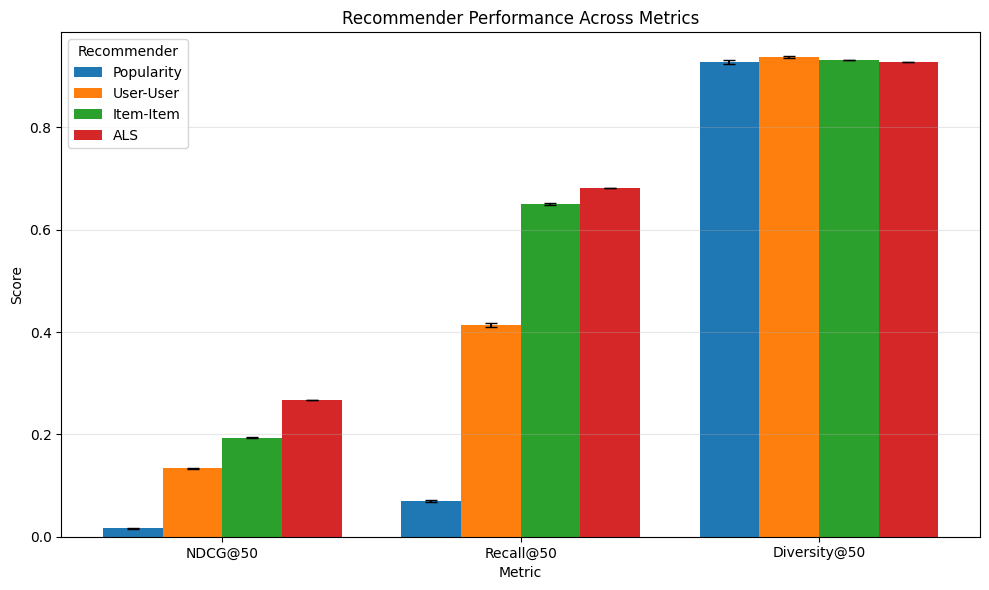

In [19]:
means_df = pd.DataFrame({
    f"NDCG@{k}": summary_ndcg[f"Mean NDCG@{k}"],
    f"Recall@{k}": summary_recall[f"Mean Recall@{k}"],
    f"Diversity@{k}": summary_diversity[f"Mean Diversity@{k}"],
}).T

stds_df = pd.DataFrame({
    f"NDCG@{k}": summary_ndcg[f"Std NDCG@{k}"],
    f"Recall@{k}": summary_recall[f"Std Recall@{k}"],
    f"Diversity@{k}": summary_diversity[f"Std Diversity@{k}"],
}).T

x = np.arange(len(means_df.index))
n_models = len(means_df.columns)
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, col in enumerate(means_df.columns):
    ax.bar(
        x + (i - (n_models - 1) / 2) * width,
        means_df[col].values,
        width=width,
        yerr=stds_df[col].values,
        capsize=4,
        label=col,
    )

ax.set_title("Recommender Performance Across Metrics")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(means_df.index)
ax.legend(title="Recommender")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Summary
The graph above indicates that the quality of recommendations varies significantly for **NDCG@50** and **Recall@50**, where **ALS performs the best**, followed by **Item-Item**, and then **User-User**, with **Popularity** being significantly behind. On the other hand, the quality of recommendations for **Diversity@50** is high and similar for all the recommenders with small differences. The overall conclusion is that **ALS performs the best for personalized ranking with no significant sacrifice in diversity**.

## Proof of Concept

After having determined that Latent-Factor Collaborative Filtering is best used for the task of recommending assets within the given context of StockTwits messages, the proponents next examined briefly a future direction for the study. That is, whether these recommenders can be integrated with a portfolio construction framework. This next stage is not intended to qualify any recommender systems, but is intended to be a prof of concept for showing how recommended assets can be translated into more sound investment allocations

In [20]:
investor_id = 5
util.loc[investor_id].dropna()

symbol
AAPL     1.0
CSCO     1.0
EFX      0.0
GOOG     1.0
GOOGL    1.0
LULU     1.0
MTCH     1.0
PYPL     1.0
TSLA     1.0
VRSN     1.0
Name: 5, dtype: float64

### Individual Investor
Take, for example, investor 5. Their ratings indicate they have a preference, for the technology, industrials, consumer, financials, and consumer sectors. Note that these sectors were determined after the fact, and is not embedded in the learning of the recommendation system itself.

| Ticker | Company                 | Sector                 |
| ------ | ----------------------- | ---------------------- |
| AAPL   | Apple Inc.              | Information Technology |
| CSCO   | Cisco                   | Information Technology |
| EFX    | Equifax                 | Industrials            |
| GOOG   | Alphabet Inc. (Class C) | Communication Services |
| GOOGL  | Alphabet Inc. (Class A) | Communication Services |
| LULU   | Lululemon Athletica     | Consumer Discretionary |
| MTCH   | Match Group             | Communication Services |
| PYPL   | PayPal                  | Financials             |
| TSLA   | Tesla, Inc.             | Consumer Discretionary |
| VRSN   | Verisign                | Information Technology |


In [21]:
end_date = "2018-01-01"
start_date = "2017-01-01"
risk_free_daily = 0.04 / 252
tau = 0.01
view_return_scale = 0.03 / 252
n_random = 5000
seed = 42
top_n = 20
n_views = top_n // 2  # e.g. 5 views for top-50

### Optimizer Inputs
- `start_date` indicates the starting date for the creation of the covariance matrix among from the historical returns of recommended assets.   
- `end_date` indicates the end date for the covariance matrix estimation as mentioned above, and the start date for the calculation of the cumulative returns    
- `tau` is a scaling factor, indicating how much "trust" to put into the investor's views relative to historical returns when estimating expected asset returns [7][9].
- `risk_free_daily` is an arbitrary risk-free rate of 4%, divided across 252 trading days. This is used to set a hurdle rate for a max-sharpe portfolio [8].    
- `top_n` Top 20 was chosen to keep the portfolio focused on the recommender’s strongest picks while still allowing some (albeit subpar) diversification. This number was capped at 20, as it is something that is still practically manageable for an investor.

In [22]:
# 1) investor-specific top-N recommendation universe from existing ALS outputs
rec_scores = blr.investor_recommender_scores_als(
    M=util,
    U=U,
    V=V,
    investor_id=investor_id,
    assets=pd.Index(util.columns.astype(str)),
    exclude_observed=True,
).dropna()

top_assets = pd.Index(rec_scores.head(top_n).index.astype(str))
if len(top_assets) < 2:
    raise ValueError("Not enough recommended unseen assets in the top-N universe.")

display(rec_scores.head(top_n).rename("als_score").to_frame())

,als_score
symbol,
MRNA,1.844939
INTC,1.555191
HOLX,1.535463
SJM,1.533739
TXT,1.514941
HLT,1.438424
ZTS,1.435826
VZ,1.434541
TXN,1.412433


### Asset Recommendations
It seems the general pattern of recommending assets in the technology, industrials, consumer, financials, and consumer sectors has persisted. New sectors such as healthcare and real estate have also appeared in the recommendations.
| Ticker | Company                   | Sector                 |
| ------ | ------------------------- | ---------------------- |
| MRNA   | Moderna                   | Health Care            |
| INTC   | Intel                     | Information Technology |
| HOLX   | Hologic                   | Health Care            |
| SJM    | J. M. Smucker             | Consumer Staples       |
| TXT    | Textron                   | Industrials            |
| HLT    | Hilton Worldwide Holdings | Consumer Discretionary |
| ZTS    | Zoetis                    | Health Care            |
| VZ     | Verizon                   | Communication Services |
| TXN    | Texas Instruments         | Information Technology |
| INTU   | Intuit                    | Information Technology |
| COF    | Capital One Financial     | Financials             |
| O      | Realty Income             | Real Estate            |
| DOC    | Healthpeak Properties     | Real Estate            |
| PAYX   | Paychex                   | Industrials            |
| ICE    | Intercontinental Exchange | Financials             |
| WFC    | Wells Fargo               | Financials             |
| MCD    | McDonald’s                | Consumer Discretionary |
| AMZN   | Amazon                    | Consumer Discretionary |
| NVDA   | NVIDIA                    | Information Technology |
| KO     | Coca-Cola                 | Consumer Staples       |


In [23]:
# 2) train/test split on that restricted universe
returns_sub = returns_matrix.reindex(columns=top_assets)
returns_sub = returns_sub.loc[start_date:].dropna(how="all", axis=1)
raw = ma.fit_raw_markowitz(
    returns_matrix=returns_sub,
    stock_data=stock_data,
    end_date=end_date,
    risk_free=risk_free_daily,
    num_random=0,
)

# 3) Ledoit-Wolf covariance prior from training returns
sigma_prior = LedoitWolf().fit(raw.R_train).covariance_

# 4) build BL views directly from existing ALS scores
scores_sub = rec_scores.reindex(raw.tickers).dropna()

P, Q, Omega, view_table = blr.build_relative_views_from_scores(
    scores=scores_sub,
    tickers=raw.tickers,
    sigma_prior=sigma_prior,
    tau=tau,
    # n_views=n_views,
    view_return_scale=view_return_scale,
)

posterior_mu, posterior_sigma = blr.black_litterman_posterior(
    prior_mu=raw.mu_train,
    sigma_prior=sigma_prior,
    P=P,
    Q=Q,
    Omega=Omega,
    tau=tau,
)

# 5) optimized portfolio weights (max-Sharpe)
_, _, weights_bl = ut.min_vol_max_sharpe(
    posterior_mu,
    posterior_sigma,
    len(raw.tickers),
    raw.returns_train,
    risk_free_rate=risk_free_daily,
)

w_opt = weights_bl[1]  # [0] min-vol, [1] max-Sharpe

# 6) optimized out-of-sample cumulative return
returns_test = raw.returns_test.reindex(columns=raw.tickers).dropna(how="any")
returns_test = returns_test.loc[: pd.to_datetime(end_date) + pd.Timedelta(weeks=52)]
cum_opt, ret_opt = ut.compute_portfolio_cumret(w_opt, returns_test)
opt_final = float(cum_opt.iloc[-1] - 1.0)

# 7) Dirichlet-random benchmark on exact same universe / window
rng = np.random.default_rng(seed)
rand_final = []

for w in rng.dirichlet(np.ones(len(raw.tickers)), size=n_random):
    w_rand = pd.Series(w, index=raw.tickers)
    cum_rand, _ = ut.compute_portfolio_cumret(w_rand, returns_test)
    rand_final.append(float(cum_rand.iloc[-1] - 1.0))

rand_final = pd.Series(rand_final, name="random_cum_return")
pctile = 100 * (rand_final <= opt_final).mean()

summary = pd.DataFrame({
    "Metric": [
        "Optimized cumulative return",
        "Random mean cumulative return",
        "Random std cumulative return",
        "Optimized percentile vs random",
    ],
    "Value": [
        opt_final,
        rand_final.mean(),
        rand_final.std(ddof=1),
        pctile,
    ],
})

### Recommendations as Portfolio Optimizer Inputs
The Recommended assets were inserted into the Black-Litterman and Markowitz Optimization Framework [7][8][9][10]. The scores given by the recommender was used to construct "investor views," or what the investor expects the relative performances of the assets are to each other.

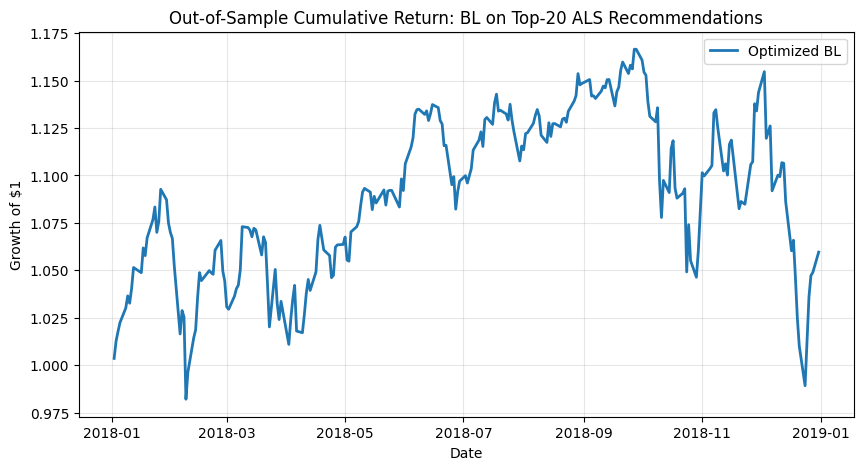

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(cum_opt.index, cum_opt.values, linewidth=2, label="Optimized BL")
plt.title(f"Out-of-Sample Cumulative Return: BL on Top-{top_n} ALS Recommendations")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Optimized Portfolio Returns
The optimized Black-Litterman portfolio built on the top-20 ALS recommendations generated a positive but volatile out-of-sample path over 2018. It rose steadily through the middle of the year, peaked at roughly 1.16–1.17 growth of $1, then gave back a meaningful portion of those gains late in the period before ending only modestly above its starting value.

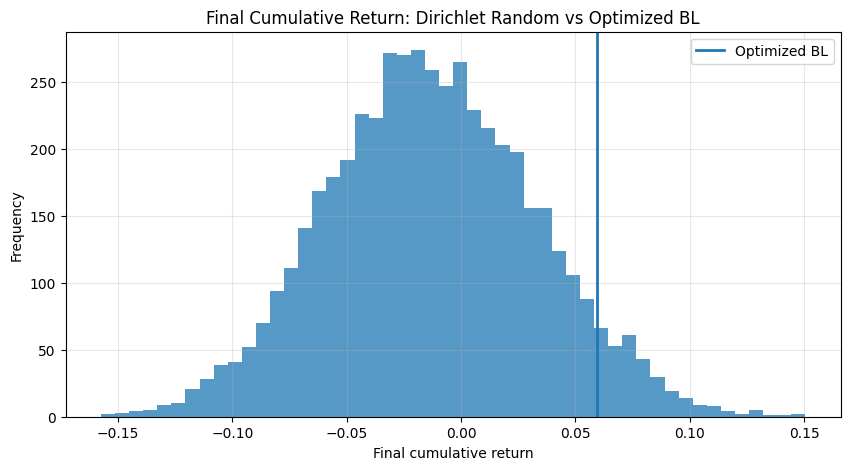

In [25]:
plt.figure(figsize=(10, 5))
plt.hist(rand_final.dropna(), bins=50, alpha=0.75)
plt.axvline(opt_final, linewidth=2, label="Optimized BL")
plt.title(f"Final Cumulative Return: Dirichlet Random vs Optimized BL")
plt.xlabel("Final cumulative return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Optimized Portfolio Performance vs Random Allocation
The histogram above represents the distribution of final cumulative returns from 5000 random portfolios created with a Dirichlet distribution, and the vertical line represents the optimized result of the Black-Litterman model. Based on the histogram, it is clear that the optimized result is positioned well to the right, indicating that the optimized portfolio performed better than most of the random portfolios created from the same set of assets.

This is a clear indicator that the recommender optimization pipeline created a better result than a random allocation. However, it is also clear that the result is positioned well to the right but not in the extreme right, indicating that it is a good result but not an overwhelming one.

## Conclusion

The goal of this study was to determine whether the performance of the personalized stock recommendation could be improved by the use of collaborative filtering approaches based on the user asset sentiment interactions on StockTwits and whether the recommendations produced by the approaches could be used for portfolio construction. From the study, it was evident that ALS had the highest NDCG@50 and Recall@50 among all the recommenders. Item-Item and User-User recommenders had the second and third highest NDCG and Recall values, respectively. On the other hand, the Popularity non-personalized approach had the lowest NDCG and Recall values. The Diversity@50 values were high and similar for all the approaches. This indicates that the improvement in the performance of ALS was not accompanied by a corresponding decrease in the diversity of the recommendations produced by the approach. From the study, it is evident that the latent factor-based collaborative filtering approach is more appropriate for the sparse user asset sentiment setting than the non-personalized approaches. ALS was the best among the approaches for recommending the relevant assets and for increasing the number of relevant assets retrieved among the top 50.

To illustrate this, the best-performing recommender was incorporated into a Black-Litterman-Markowitz process. The optimized portfolio, using the top 20 ALS recommendations as a personalized set, generated a positive though volatile out-of-sample return series, beating most randomly generated portfolios using a similar set of assets, weighted by a Dirichlet process. This, of course, does not prove that portfolios using any of these recommenders will outperform the market, but rather demonstrates that a portfolio process using the output of a financial recommender system is possible.

## Recommendations

1. Future work could explore implicit asset ratings from current portfolio holdings. As an example, the delta in absolute amount allocated for a certain asset across time, or the delta in the weight of that asset in relation to the whole portfolio could be used as proxies for ratings. This, coupled with further investigation of investor behavior in terms of risk appetite could yield novel results in the realm of financial recommender systems.   
2. It is to the researchers' knowledge that cryptocurrency prices and returns are associated with investor sentiment [12]. Given the nature of the recommender system and dataset used, the researchers recommend expanding the work to include, or even solely focus on cryptocurrencies. Compared to traditional investment assets such as those in the S&P500, cryptocurrencies are often more retail-driven, more reactive to online sentiment, and more volatile, making them a particularly good setting for sentiment-based recommendaiton.
3. Future work should assess the recommender models across various time intervals and market regimes instead of a single downstream test window. This will help us understand whether the advantage of ALS persists in bull, bear, and high volatility regimes

## References:
[1] Li, X., Al Ansari, N., and Kaufman, A. 2025. StockTwits: Comprehensive records of a financial social media platform from 2008 to 2022. Journal of Quantitative Description: Digital Media 5. https://doi.org/10.51685/jqd.2025.020

[2] hanshof. n.d. sp500_constituents. GitHub repository. GitHub. Accessed March 12, 2026.

[3] Aroussi, R. 2026. yfinance. Python package. PyPI. Accessed March 12, 2026.

[4] Avellaneda, M., & Lee, J. H. (2010). Statistical arbitrage in the US equities market. Quantitative Finance, 10(7), 761-782.

[5] Ji, Y., Sun, A., Zhang, J., and Li, C. 2020. A re-visit of the popularity baseline in recommender systems. In Proceedings of the 43rd International ACM SIGIR Conference on Research and Development in Information Retrieval. ACM.

[6] Zangerle, E. and Bauer, C. 2022. Evaluating recommender systems: Survey and framework. ACM Computing Surveys 55, 8, Article 170, 38 pages. https://doi.org/10.1145/3556536

[7] Martin, R. A. 2021. PyPortfolioOpt: portfolio optimization in Python. *Journal of Open Source Software* 6, 61, 3066. [https://doi.org/10.21105/joss.03066](https://doi.org/10.21105/joss.03066)

[8] Bloomberg L.P. (n.d.). United States government bonds: Rates & markets. Bloomberg. https://www.bloomberg.com/markets/rates-bonds/government-bonds/us
 
[9] Horváth, Ágota & Kazarian, Kazaros. (2017). The Dirichlet problem in weighted norm. Acta Mathematica Hungarica. 153. 34-. 10.1007/s10474-017-0749-8.

[10] Markowitz, H. (1952). Portfolio selection. The Journal of Finance, 7(1), 77-91.
      
[11] Plotly Technologies Inc. (n.d.). Markowitz portfolio optimization in Python/v3. Retrieved from https://plotly.com/python/v3/ipython-notebooks/markowitz-portfolio-optimization/

[12] Koutmos, D. 2022. Investor sentiment and bitcoin prices. Research in International Business and Finance 63, 101757. https://doi.org/10.1016/j.ribaf.2022.101757